# Filter test and studies

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys

sys.path.append("../")
from utils.filter_functions import ray_seg_matching, ray_rect_matching

### matching probes

P1
Segment 1 -> 2
NO INTERSECTS
Segment 2 -> 3
INTERSECTS
Segment 3 -> 4
NO INTERSECTS
Segment 4 -> 5
INTERSECTS
---------
P2
Segment 1 -> 2
NO INTERSECTS
Segment 2 -> 3
NO INTERSECTS
Segment 3 -> 4
NO INTERSECTS
Segment 4 -> 5
NO INTERSECTS
---------
P1 and Rect defined by vertices 1-2-3-4
INTERSECTS
---------
P2 and Rect defined by vertices 1-2-3-4
NO INTERSECTS


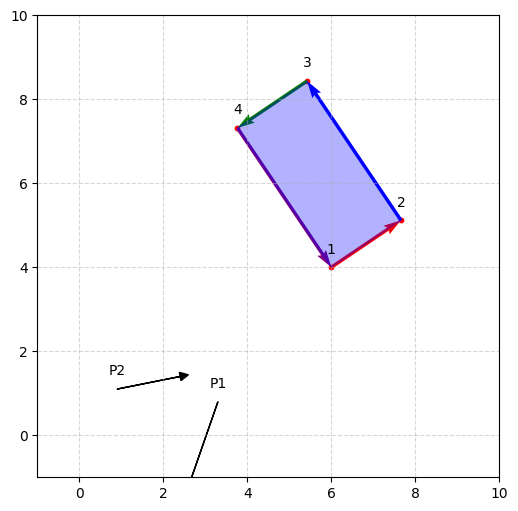

In [2]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ax.grid(True, alpha=0.5, linestyle='--')
ax.set_xlim(-1, 10)
ax.set_ylim(-1, 10)

#def the rectangle
rect = plt.Rectangle((6,4), 2, 4, linewidth=1, color='blue', angle=34, alpha=0.3)
vertices = np.array(rect.get_verts())
segments = np.diff(vertices, axis=0)

for i, (x, y) in enumerate(vertices[:-1], start=1):
    ax.scatter(x, y, color='red', s=10)
    ax.annotate(f"{i}", xy=(x, y), textcoords="offset points", xytext=(0, 10), ha='center')


ax.quiver(vertices[:-1, 0], vertices[:-1, 1], segments[:, 0], segments[:, 1], color=['red', 'blue', 'green', 'purple'], scale_units='xy', scale=1)

p1 = np.array([3.3, 0.8])
p2 = np.array([0.9, 1.1])
d1 = -1 * np.array([0.8, 2.3])
d2 = np.array([1.5, 0.3])

ax.arrow(*p1, *d1, head_width=0.2, head_length=0.2, color="k")
ax.annotate("P1", xy=p1, textcoords="offset points", xytext=(0, 10), ha='center')
ax.arrow(*p2, *d2, head_width=0.2, head_length=0.2, color="k")
ax.annotate("P2", xy=p2, textcoords="offset points", xytext=(0, 10), ha='center')

# Check if the ray intersects with the segment
# for p1 and d1 
print("P1")
for i in range(len(vertices)-1):
    a = vertices[i]
    b = vertices[i + 1]
    print(f"Segment {i+1} -> {i+2}")
    if ray_seg_matching(p1, d1, a, b):
        print(f"INTERSECTS")
    else:
        print(f"NO INTERSECTS")
# for p2 and d2
print("---------\nP2")
for i in range(len(vertices) - 1):
    a = vertices[i]
    b = vertices[i + 1]
    print(f"Segment {i+1} -> {i+2}")
    if ray_seg_matching(p2, d2, a, b):
        print(f"INTERSECTS")
    else:
        print(f"NO INTERSECTS")


# Check if the ray intersects with the rectangle
print("---------\nP1 and Rect defined by vertices 1-2-3-4")
if ray_rect_matching(p1, d1, vertices[:-1]):
    print("INTERSECTS")
else:
    print("NO INTERSECTS")
print("---------\nP2 and Rect defined by vertices 1-2-3-4")
if ray_rect_matching(p2, d2, vertices[:-1]):
    print("INTERSECTS")
else:
    print("NO INTERSECTS")

ax.add_patch(rect)
ax.set_aspect("equal")
plt.show()